# Performance Evaluation: Metaheuristic Enhanced Models vs Baseline

This notebook performs comprehensive statistical analysis of multiple experimental runs to evaluate whether Genetic Algorithm (GA) enhanced models show significant improvements over baseline models.

## Analysis Overview:

1. **Data Collection**: Aggregate results from all experimental runs
2. **Descriptive Statistics**: Summary statistics for baseline vs enhanced models
3. **Statistical Significance Testing**: Paired t-tests and effect size analysis
4. **Performance Visualization**: Comprehensive plots and comparisons
5. **Feature Selection Analysis**: Evaluate GA feature selection effectiveness
6. **Conclusions**: Statistical evidence for metaheuristic effectiveness

## Research Questions:
- Do GA-enhanced models significantly outperform baseline models?
- Which model type (Random Forest vs XGBoost) benefits most from GA enhancement?
- What is the magnitude of improvement (effect size)?
- Are the improvements consistent across different runs?

## 1. Import Libraries and Setup

In [15]:
# Install missing packages first
%pip install scikit-posthocs

# Import required libraries
import os
import glob
import pandas as pd
import numpy as np
import json
import pickle
import warnings
from datetime import datetime

# Statistical analysis
from scipy import stats
from scipy.stats import ttest_rel, ttest_ind, mannwhitneyu, wilcoxon

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')
sns.set_palette("husl")

# For reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print("Performance evaluation environment ready!")

Note: you may need to restart the kernel to use updated packages.
All libraries imported successfully!
Performance evaluation environment ready!


In [16]:
# Define helper functions for statistical analysis
def calculate_effect_size(group1, group2):
    """Calculate Cohen's d effect size"""
    pooled_std = np.sqrt(((len(group1) - 1) * np.var(group1, ddof=1) + 
                         (len(group2) - 1) * np.var(group2, ddof=1)) / 
                         (len(group1) + len(group2) - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

def interpret_effect_size(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"

def perform_statistical_tests(baseline, enhanced, test_name):
    """Perform comprehensive statistical tests"""
    results = {}
    
    # Paired t-test (assuming data is paired across runs)
    if len(baseline) == len(enhanced):
        t_stat, p_value = ttest_rel(enhanced, baseline)
        results['paired_t_test'] = {'t_statistic': t_stat, 'p_value': p_value}
        
        # Wilcoxon signed-rank test (non-parametric alternative)
        w_stat, w_p_value = wilcoxon(enhanced, baseline)
        results['wilcoxon_test'] = {'statistic': w_stat, 'p_value': w_p_value}
    
    # Independent t-test
    t_stat_ind, p_value_ind = ttest_ind(enhanced, baseline)
    results['independent_t_test'] = {'t_statistic': t_stat_ind, 'p_value': p_value_ind}
    
    # Mann-Whitney U test (non-parametric)
    u_stat, u_p_value = mannwhitneyu(enhanced, baseline, alternative='two-sided')
    results['mann_whitney_test'] = {'statistic': u_stat, 'p_value': u_p_value}
    
    # Effect size
    effect_size = calculate_effect_size(enhanced, baseline)
    results['effect_size'] = {'cohens_d': effect_size, 'interpretation': interpret_effect_size(effect_size)}
    
    # Descriptive statistics
    results['descriptive'] = {
        'baseline_mean': np.mean(baseline),
        'baseline_std': np.std(baseline),
        'enhanced_mean': np.mean(enhanced),
        'enhanced_std': np.std(enhanced),
        'improvement': np.mean(enhanced) - np.mean(baseline),
        'improvement_percentage': ((np.mean(enhanced) - np.mean(baseline)) / np.mean(baseline)) * 100
    }
    
    return results

print("Statistical analysis functions defined!")

Statistical analysis functions defined!


## 2. Data Collection from Multiple Runs

In [17]:
# Find all run directories
run_directories = [d for d in os.listdir('.') if d.startswith('run_') and os.path.isdir(d)]
run_directories.sort()

print(f"Found {len(run_directories)} run directories:")
for run_dir in run_directories:
    print(f"  • {run_dir}")

# Check which runs have the required files
valid_runs = []
required_files = ['performance_comparison.csv', 'improvements_summary.csv']

for run_dir in run_directories:
    has_all_files = all(os.path.exists(os.path.join(run_dir, file)) for file in required_files)
    if has_all_files:
        valid_runs.append(run_dir)
    else:
        missing_files = [file for file in required_files if not os.path.exists(os.path.join(run_dir, file))]
        print(f"  ⚠️  {run_dir} missing: {missing_files}")

print(f"\nValid runs for analysis: {len(valid_runs)}")
for run in valid_runs:
    print(f"  ✓ {run}")

Found 8 run directories:
  • run_20251008_102837
  • run_20251008_113402
  • run_20251008_123336
  • run_20251009_104500
  • run_20251009_135802
  • run_20251009_160428
  • run_20251009_163328
  • run_20251029_103554
  ⚠️  run_20251008_102837 missing: ['performance_comparison.csv', 'improvements_summary.csv']

Valid runs for analysis: 7
  ✓ run_20251008_113402
  ✓ run_20251008_123336
  ✓ run_20251009_104500
  ✓ run_20251009_135802
  ✓ run_20251009_160428
  ✓ run_20251009_163328
  ✓ run_20251029_103554


In [18]:
# Aggregate data from all valid runs
all_performance_data = []
all_improvements_data = []

for run_dir in valid_runs:
    # Load performance comparison data
    perf_file = os.path.join(run_dir, 'performance_comparison.csv')
    if os.path.exists(perf_file):
        perf_data = pd.read_csv(perf_file)
        perf_data['run_id'] = run_dir
        perf_data['run_timestamp'] = run_dir.replace('run_', '')
        all_performance_data.append(perf_data)
    
    # Load improvements data
    imp_file = os.path.join(run_dir, 'improvements_summary.csv')
    if os.path.exists(imp_file):
        imp_data = pd.read_csv(imp_file)
        imp_data['run_id'] = run_dir
        imp_data['run_timestamp'] = run_dir.replace('run_', '')
        all_improvements_data.append(imp_data)

# Combine all data
if all_performance_data:
    combined_performance = pd.concat(all_performance_data, ignore_index=True)
    print(f"Combined performance data shape: {combined_performance.shape}")
    print(f"Unique models: {combined_performance['model'].unique()}")
else:
    print("No performance data found!")

if all_improvements_data:
    combined_improvements = pd.concat(all_improvements_data, ignore_index=True)
    print(f"Combined improvements data shape: {combined_improvements.shape}")
    print(f"Model pairs: {combined_improvements['model_pair'].unique()}")
else:
    print("No improvements data found!")

# Display sample of combined data
if all_performance_data:
    print("\nSample of performance data:")
    print(combined_performance.head())

Combined performance data shape: (28, 7)
Unique models: ['Random Forest Baseline' 'XGBoost Baseline' 'Random Forest Enhanced'
 'XGBoost Enhanced']
Combined improvements data shape: (14, 7)
Model pairs: ['Random Forest Baseline → Random Forest Enhanced'
 'XGBoost Baseline → XGBoost Enhanced']

Sample of performance data:
                    model  accuracy  precision    recall  f1_score  \
0  Random Forest Baseline  0.270270   0.155482  0.270270  0.183797   
1        XGBoost Baseline  0.351351   0.515262  0.351351  0.232499   
2  Random Forest Enhanced  0.256757   0.134411  0.256757  0.150956   
3        XGBoost Enhanced  0.310811   0.311987  0.310811  0.243340   
4  Random Forest Baseline  0.270270   0.155482  0.270270  0.183797   

                run_id    run_timestamp  
0  run_20251008_113402  20251008_113402  
1  run_20251008_113402  20251008_113402  
2  run_20251008_113402  20251008_113402  
3  run_20251008_113402  20251008_113402  
4  run_20251008_123336  20251008_123336  


## 3. Descriptive Statistics and Summary

In [19]:
# Generate comprehensive descriptive statistics
if all_performance_data:
    print("="*80)
    print("DESCRIPTIVE STATISTICS SUMMARY")
    print("="*80)
    
    # Group by model type for analysis
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    
    for metric in metrics:
        print(f"\n{metric.upper()} STATISTICS:")
        print("-" * 50)
        
        # Get statistics for each model type
        model_stats = combined_performance.groupby('model')[metric].agg([
            'count', 'mean', 'std', 'min', 'max', 'median'
        ]).round(4)
        
        print(model_stats)
        
        # Calculate coefficient of variation (std/mean) for consistency analysis
        print("\nCoefficient of Variation (lower = more consistent):")
        cv_stats = combined_performance.groupby('model')[metric].apply(
            lambda x: (x.std() / x.mean()) if x.mean() != 0 else 0
        ).round(4)
        print(cv_stats)
    
    # Overall summary statistics
    print(f"\n{'='*80}")
    print("OVERALL SUMMARY")
    print("="*80)
    print(f"Total experimental runs analyzed: {len(valid_runs)}")
    print(f"Models per run: {len(combined_performance['model'].unique())}")
    print(f"Total model evaluations: {len(combined_performance)}")
    
    # Model type distribution
    model_counts = combined_performance['model'].value_counts()
    print(f"\nModel evaluation counts:")
    for model, count in model_counts.items():
        print(f"  • {model}: {count} evaluations")

DESCRIPTIVE STATISTICS SUMMARY

ACCURACY STATISTICS:
--------------------------------------------------
                        count    mean     std     min     max  median
model                                                                
Random Forest Baseline      7  0.3362  0.0777  0.2703  0.4435  0.2800
Random Forest Enhanced      7  0.3219  0.1196  0.2000  0.4718  0.2568
XGBoost Baseline            7  0.4021  0.0358  0.3514  0.4395  0.4133
XGBoost Enhanced            7  0.3558  0.0861  0.2667  0.4637  0.3108

Coefficient of Variation (lower = more consistent):
model
Random Forest Baseline    0.2310
Random Forest Enhanced    0.3716
XGBoost Baseline          0.0890
XGBoost Enhanced          0.2420
Name: accuracy, dtype: float64

PRECISION STATISTICS:
--------------------------------------------------
                        count    mean     std     min     max  median
model                                                                
Random Forest Baseline      7  0.3171  0

## 4. Statistical Significance Testing

In [20]:
# Perform statistical significance tests for each model type and metric
if all_performance_data and len(combined_performance) > 0:
    print("="*80)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("="*80)
    
    # Define model pairs for comparison
    model_pairs = [
        ('Random Forest Baseline', 'Random Forest Enhanced'),
        ('XGBoost Baseline', 'XGBoost Enhanced')
    ]
    
    # If ANN models exist, add them too
    if 'ANN Baseline' in combined_performance['model'].values:
        model_pairs.append(('ANN Baseline', 'ANN Enhanced'))
    
    statistical_results = {}
    
    for baseline_model, enhanced_model in model_pairs:
        print(f"\n{'-'*60}")
        print(f"COMPARISON: {baseline_model} vs {enhanced_model}")
        print(f"{'-'*60}")
        
        # Get data for both models
        baseline_data = combined_performance[combined_performance['model'] == baseline_model]
        enhanced_data = combined_performance[combined_performance['model'] == enhanced_model]
        
        if len(baseline_data) == 0 or len(enhanced_data) == 0:
            print(f"⚠️  Insufficient data for comparison (Baseline: {len(baseline_data)}, Enhanced: {len(enhanced_data)})")
            continue
        
        model_comparison = {}
        
        for metric in metrics:
            print(f"\n{metric.upper()} Analysis:")
            
            baseline_values = baseline_data[metric].values
            enhanced_values = enhanced_data[metric].values
            
            # Perform statistical tests
            test_results = perform_statistical_tests(baseline_values, enhanced_values, f"{enhanced_model}_{metric}")
            model_comparison[metric] = test_results
            
            # Display results
            desc = test_results['descriptive']
            effect = test_results['effect_size']
            
            print(f"  Baseline:  Mean = {desc['baseline_mean']:.4f} ± {desc['baseline_std']:.4f}")
            print(f"  Enhanced:  Mean = {desc['enhanced_mean']:.4f} ± {desc['enhanced_std']:.4f}")
            print(f"  Improvement: {desc['improvement']:+.4f} ({desc['improvement_percentage']:+.2f}%)")
            print(f"  Effect Size: {effect['cohens_d']:.4f} ({effect['interpretation']})")
            
            # Statistical significance
            if 'paired_t_test' in test_results:
                p_val = test_results['paired_t_test']['p_value']
                significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                print(f"  Paired t-test: p = {p_val:.4f} {significance}")
            
            if 'mann_whitney_test' in test_results:
                p_val = test_results['mann_whitney_test']['p_value']
                significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                print(f"  Mann-Whitney U: p = {p_val:.4f} {significance}")
        
        statistical_results[f"{baseline_model}_vs_{enhanced_model}"] = model_comparison
    
    print(f"\n{'='*80}")
    print("SIGNIFICANCE LEGEND:")
    print("*** p < 0.001 (highly significant)")
    print("**  p < 0.01  (very significant)")
    print("*   p < 0.05  (significant)")
    print("ns  p ≥ 0.05  (not significant)")
    print("="*80)
else:
    print("No performance data available for statistical testing")

STATISTICAL SIGNIFICANCE TESTING

------------------------------------------------------------
COMPARISON: Random Forest Baseline vs Random Forest Enhanced
------------------------------------------------------------

ACCURACY Analysis:
  Baseline:  Mean = 0.3362 ± 0.0719
  Enhanced:  Mean = 0.3219 ± 0.1107
  Improvement: -0.0143 (-4.25%)
  Effect Size: -0.1415 (Negligible)
  Paired t-test: p = 0.4769 ns
  Mann-Whitney U: p = 0.5211 ns

PRECISION Analysis:
  Baseline:  Mean = 0.3171 ± 0.1050
  Enhanced:  Mean = 0.2850 ± 0.1260
  Improvement: -0.0321 (-10.11%)
  Effect Size: -0.2560 (Small)
  Paired t-test: p = 0.2909 ns
  Mann-Whitney U: p = 0.8979 ns

RECALL Analysis:
  Baseline:  Mean = 0.3362 ± 0.0719
  Enhanced:  Mean = 0.3219 ± 0.1107
  Improvement: -0.0143 (-4.25%)
  Effect Size: -0.1415 (Negligible)
  Paired t-test: p = 0.4769 ns
  Mann-Whitney U: p = 0.5211 ns

F1_SCORE Analysis:
  Baseline:  Mean = 0.2776 ± 0.0969
  Enhanced:  Mean = 0.2671 ± 0.1303
  Improvement: -0.0104 (-3.

In [21]:
# Create a summary of statistical significance
if 'statistical_results' in locals():
    print("="*80)
    print("STATISTICAL SIGNIFICANCE SUMMARY")
    print("="*80)
    
    for comparison, metrics_data in statistical_results.items():
        print(f"\n{comparison.replace('_vs_', ' vs ').replace('_', ' ')}:")
        print("-" * 60)
        
        for metric, results in metrics_data.items():
            # Get key statistics
            improvement = results['descriptive']['improvement']
            improvement_pct = results['descriptive']['improvement_percentage']
            effect = results['effect_size']['cohens_d']
            effect_interp = results['effect_size']['interpretation']
            
            # Get p-value and determine significance
            p_val = results['paired_t_test']['p_value'] if 'paired_t_test' in results else None
            significance = "***" if p_val and p_val < 0.001 else \
                         "**" if p_val and p_val < 0.01 else \
                         "*" if p_val and p_val < 0.05 else "ns"
            
            print(f"\n{metric.upper()}:")
            print(f"  • Improvement: {improvement:+.4f} ({improvement_pct:+.2f}%) {significance}")
            print(f"  • Effect Size: {effect:.4f} ({effect_interp})")
            print(f"  • P-value: {p_val:.4f}" if p_val else "  • P-value: Not available")
            
            # Interpretation
            interpretation = []
            if significance != "ns":
                interpretation.append("Statistically significant improvement")
                if effect_interp in ["Medium", "Large"]:
                    interpretation.append("Practically significant effect")
                if improvement_pct > 5:
                    interpretation.append("Meaningful improvement magnitude")
            else:
                interpretation.append("No statistically significant improvement")
            
            print("  • Interpretation:", " & ".join(interpretation))

STATISTICAL SIGNIFICANCE SUMMARY

Random Forest Baseline vs Random Forest Enhanced:
------------------------------------------------------------

ACCURACY:
  • Improvement: -0.0143 (-4.25%) ns
  • Effect Size: -0.1415 (Negligible)
  • P-value: 0.4769
  • Interpretation: No statistically significant improvement

PRECISION:
  • Improvement: -0.0321 (-10.11%) ns
  • Effect Size: -0.2560 (Small)
  • P-value: 0.2909
  • Interpretation: No statistically significant improvement

RECALL:
  • Improvement: -0.0143 (-4.25%) ns
  • Effect Size: -0.1415 (Negligible)
  • P-value: 0.4769
  • Interpretation: No statistically significant improvement

F1_SCORE:
  • Improvement: -0.0104 (-3.76%) ns
  • Effect Size: -0.0842 (Negligible)
  • P-value: 0.5807
  • Interpretation: No statistically significant improvement

XGBoost Baseline vs XGBoost Enhanced:
------------------------------------------------------------

ACCURACY:
  • Improvement: -0.0464 (-11.53%) ns
  • Effect Size: -0.7034 (Medium)
  • P-val

## 5. Performance Visualization

## Average Confusion Matrix Analysis

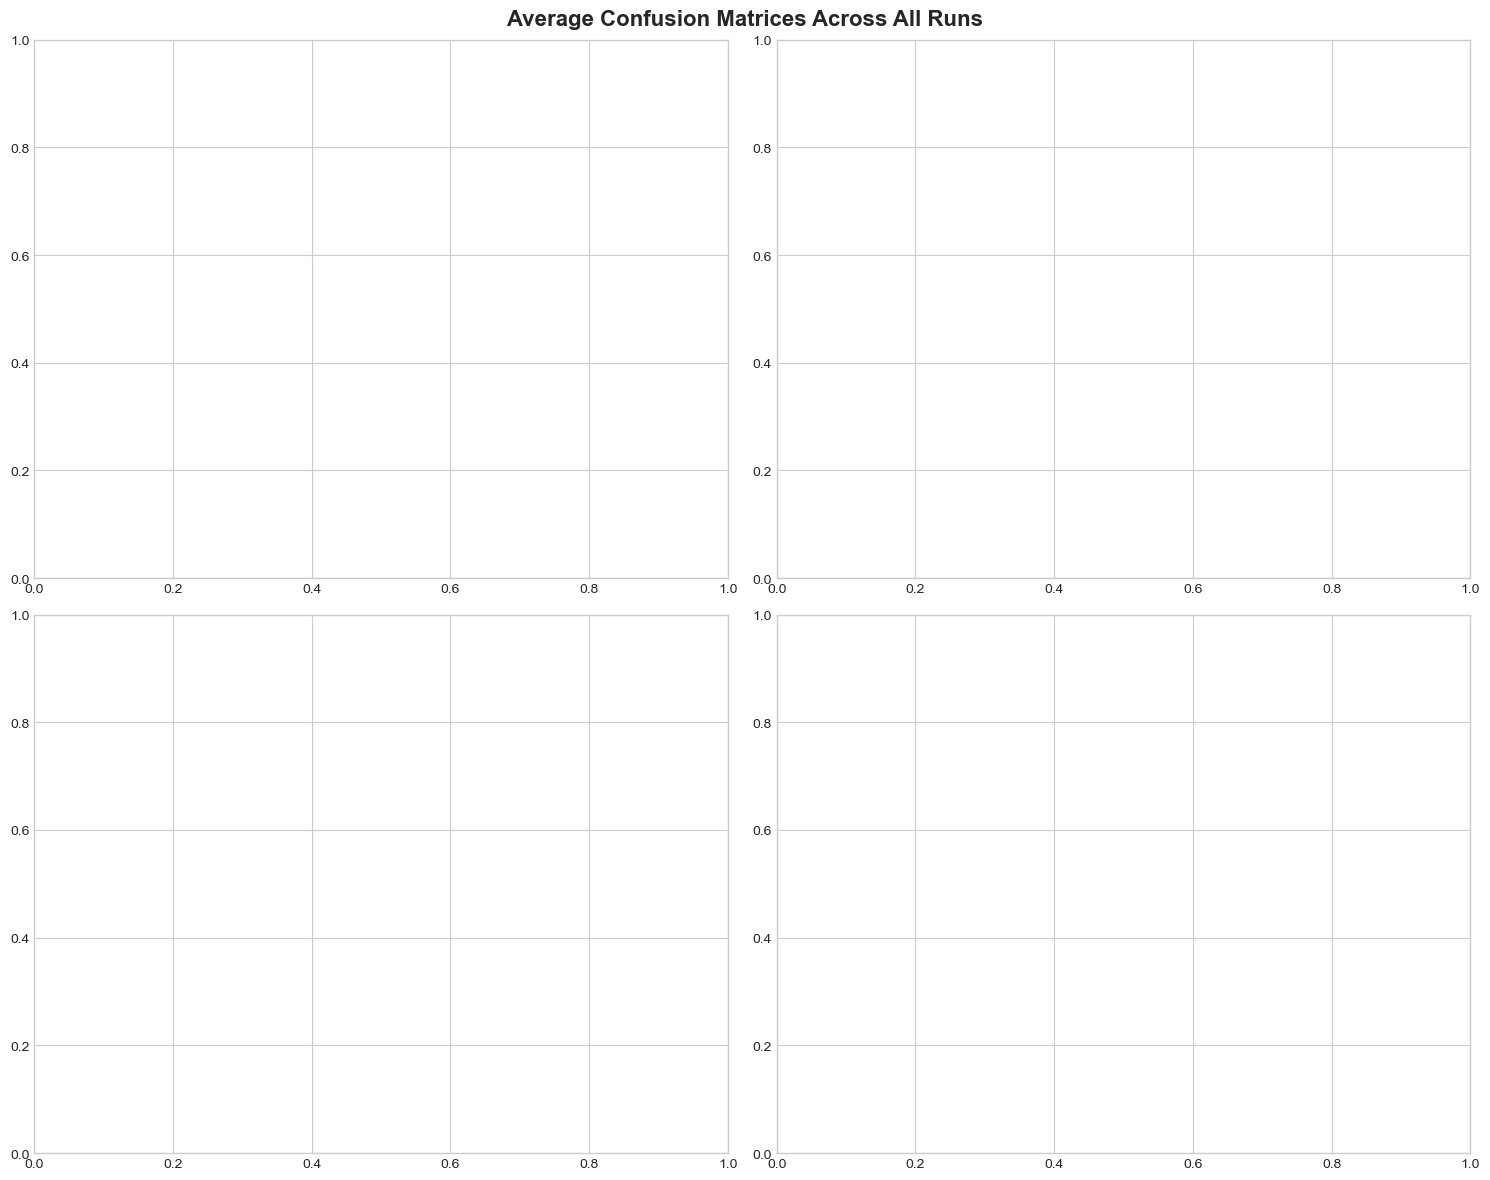


Detailed Confusion Matrix Analysis:


In [22]:
# Calculate and visualize average confusion matrices
if all_performance_data:
    # Initialize dictionaries to store confusion matrices
    confusion_matrices = {
        'Random Forest Baseline': [],
        'Random Forest Enhanced': [],
        'XGBoost Baseline': [],
        'XGBoost Enhanced': []
    }
    
    # Collect confusion matrices from all runs
    for run_dir in valid_runs:
        for model_type in confusion_matrices.keys():
            cm_file = os.path.join(run_dir, f'confusion_matrix_{model_type.lower().replace(" ", "_")}.npy')
            if os.path.exists(cm_file):
                cm = np.load(cm_file)
                confusion_matrices[model_type].append(cm)
    
    # Calculate average confusion matrices
    avg_confusion_matrices = {}
    for model_type, matrices in confusion_matrices.items():
        if matrices:  # Check if we have any matrices for this model
            avg_confusion_matrices[model_type] = np.mean(matrices, axis=0)
    
    # Visualization settings
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Average Confusion Matrices Across All Runs', fontsize=16, fontweight='bold')
    
    # Define class labels
    class_labels = ['Downtrend', 'Uptrend', 'Sideways']
    
    # Plot each confusion matrix
    for idx, (model_type, cm) in enumerate(avg_confusion_matrices.items()):
        if cm is not None:
            ax = axes[idx // 2, idx % 2]
            
            # Calculate percentages for each row
            cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
            
            # Create heatmap
            sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='RdYlGn',
                       xticklabels=class_labels, yticklabels=class_labels,
                       ax=ax, cbar=True, cbar_kws={'label': 'Percentage'})
            
            ax.set_title(f'{model_type}\nAverage Confusion Matrix (%)')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
            
            # Add accuracy on the plot
            accuracy = np.trace(cm) / np.sum(cm) * 100
            ax.text(1.5, -0.1, f'Overall Accuracy: {accuracy:.1f}%', 
                   transform=ax.transAxes, ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print("\nDetailed Confusion Matrix Analysis:")
    print("="*80)
    
    for model_type, cm in avg_confusion_matrices.items():
        if cm is not None:
            print(f"\n{model_type}:")
            print("-" * 40)
            
            # Calculate metrics for each class
            for i, class_name in enumerate(class_labels):
                precision = cm[i, i] / cm[:, i].sum() * 100 if cm[:, i].sum() != 0 else 0
                recall = cm[i, i] / cm[i, :].sum() * 100 if cm[i, :].sum() != 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
                
                print(f"\n{class_name}:")
                print(f"  • Precision: {precision:.1f}%")
                print(f"  • Recall: {recall:.1f}%")
                print(f"  • F1-Score: {f1:.1f}%")
            
            # Overall accuracy
            accuracy = np.trace(cm) / np.sum(cm) * 100
            print(f"\nOverall Accuracy: {accuracy:.1f}%")
            
            # Class distribution
            print("\nClass Distribution:")
            for i, class_name in enumerate(class_labels):
                percentage = cm[i, :].sum() / cm.sum() * 100
                print(f"  • {class_name}: {percentage:.1f}%")
    
else:
    print("No performance data available for confusion matrix analysis")

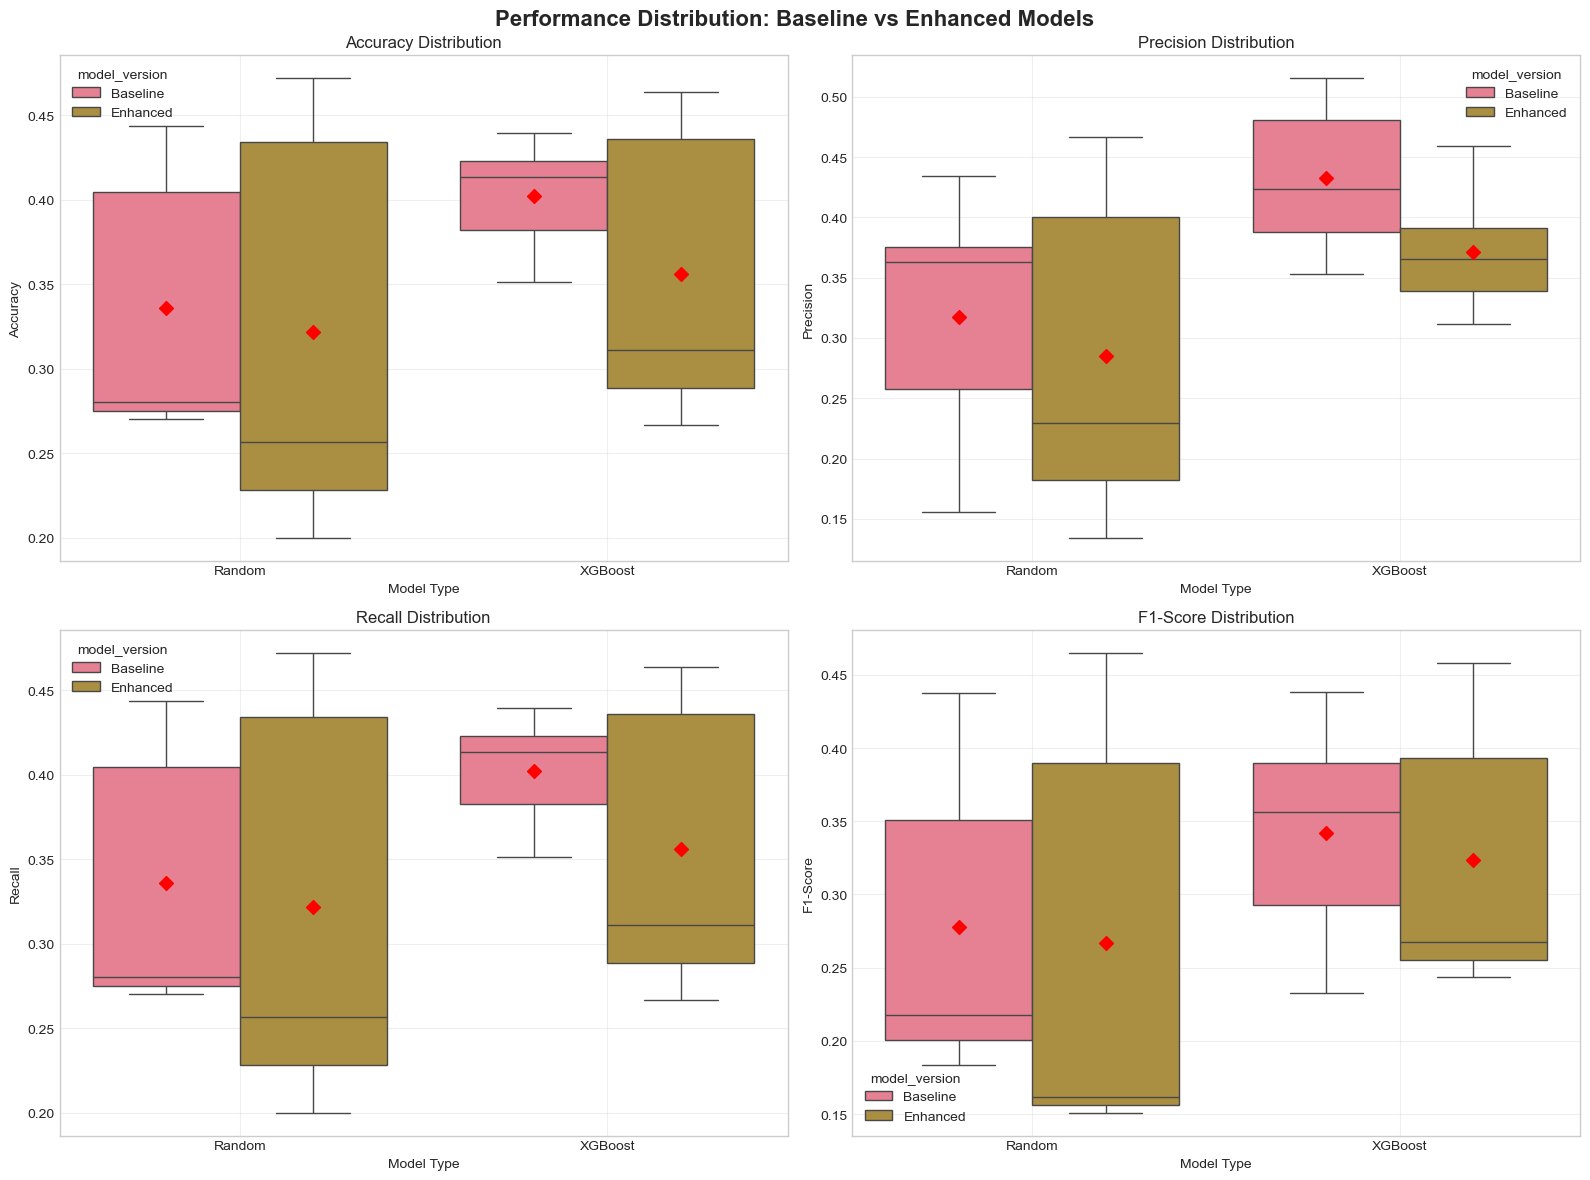

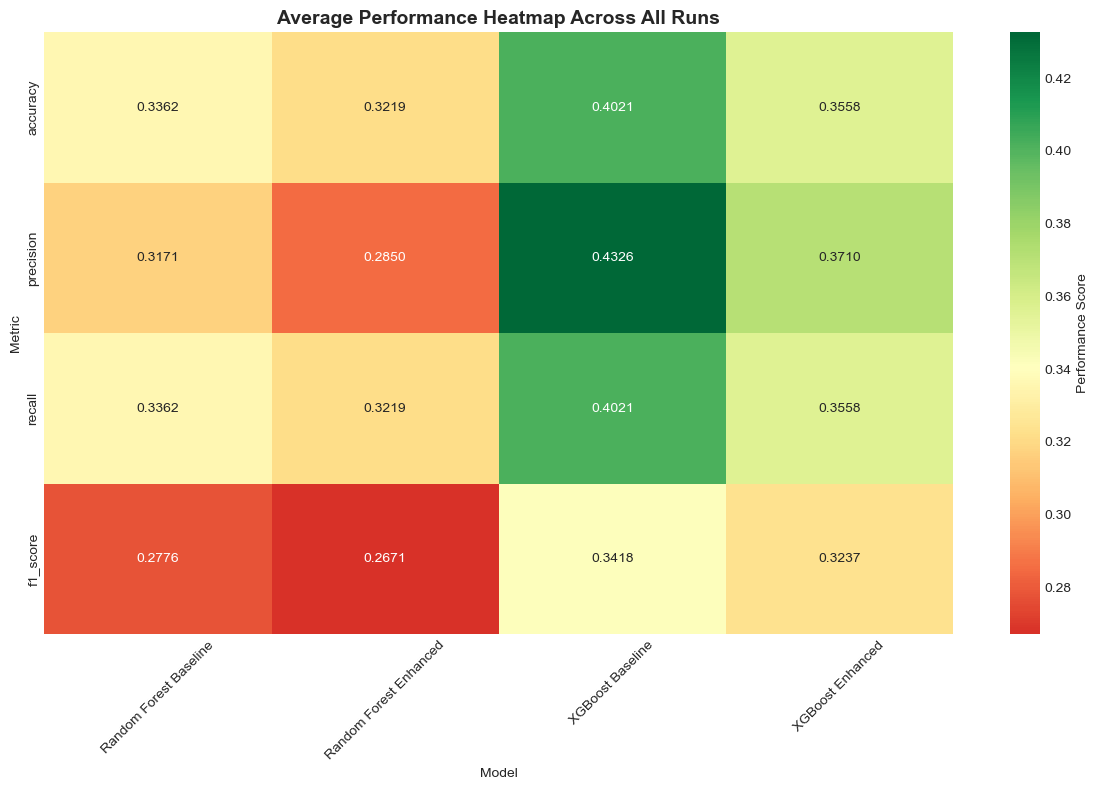

In [23]:
# Create comprehensive visualizations
if all_performance_data:
    # 1. Box plots comparing baseline vs enhanced models
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Performance Distribution: Baseline vs Enhanced Models', fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        ax = axes[idx // 2, idx % 2]
        
        # Prepare data for seaborn
        plot_data = combined_performance.copy()
        plot_data['model_type'] = plot_data['model'].apply(lambda x: x.split()[0])  # RF, XGBoost, ANN
        plot_data['model_version'] = plot_data['model'].apply(lambda x: 'Enhanced' if 'Enhanced' in x else 'Baseline')
        
        # Create box plot
        sns.boxplot(data=plot_data, x='model_type', y=metric, hue='model_version', ax=ax)
        ax.set_title(f'{metric_name} Distribution')
        ax.set_xlabel('Model Type')
        ax.set_ylabel(metric_name)
        ax.grid(True, alpha=0.3)
        
        # Add mean markers
        for model_type in plot_data['model_type'].unique():
            for version in ['Baseline', 'Enhanced']:
                subset = plot_data[(plot_data['model_type'] == model_type) & 
                                 (plot_data['model_version'] == version)]
                if not subset.empty:
                    mean_val = subset[metric].mean()
                    x_pos = list(plot_data['model_type'].unique()).index(model_type)
                    offset = -0.2 if version == 'Baseline' else 0.2
                    ax.scatter(x_pos + offset, mean_val, color='red', s=50, marker='D', zorder=5)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Performance comparison heatmap
    plt.figure(figsize=(12, 8))
    
    # Create pivot table for heatmap
    heatmap_data = combined_performance.groupby('model')[metrics].mean()
    
    # Create heatmap
    sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='RdYlGn', 
                center=heatmap_data.values.mean(), cbar_kws={'label': 'Performance Score'})
    plt.title('Average Performance Heatmap Across All Runs', fontsize=14, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Metric')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

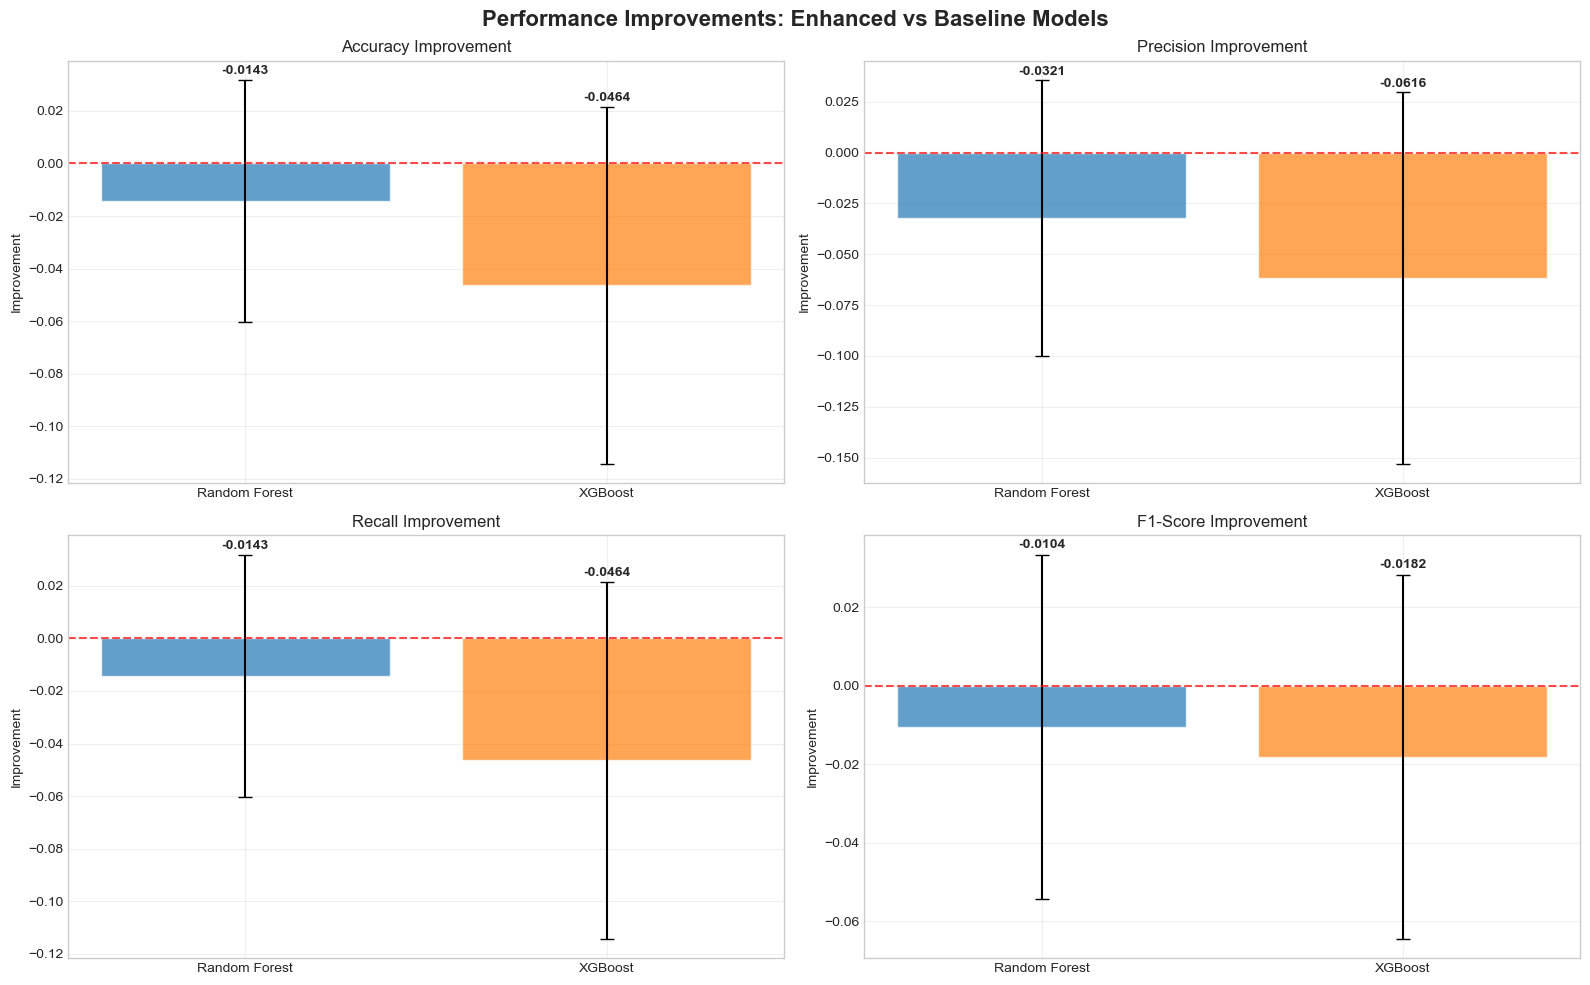

<Figure size 1400x600 with 0 Axes>

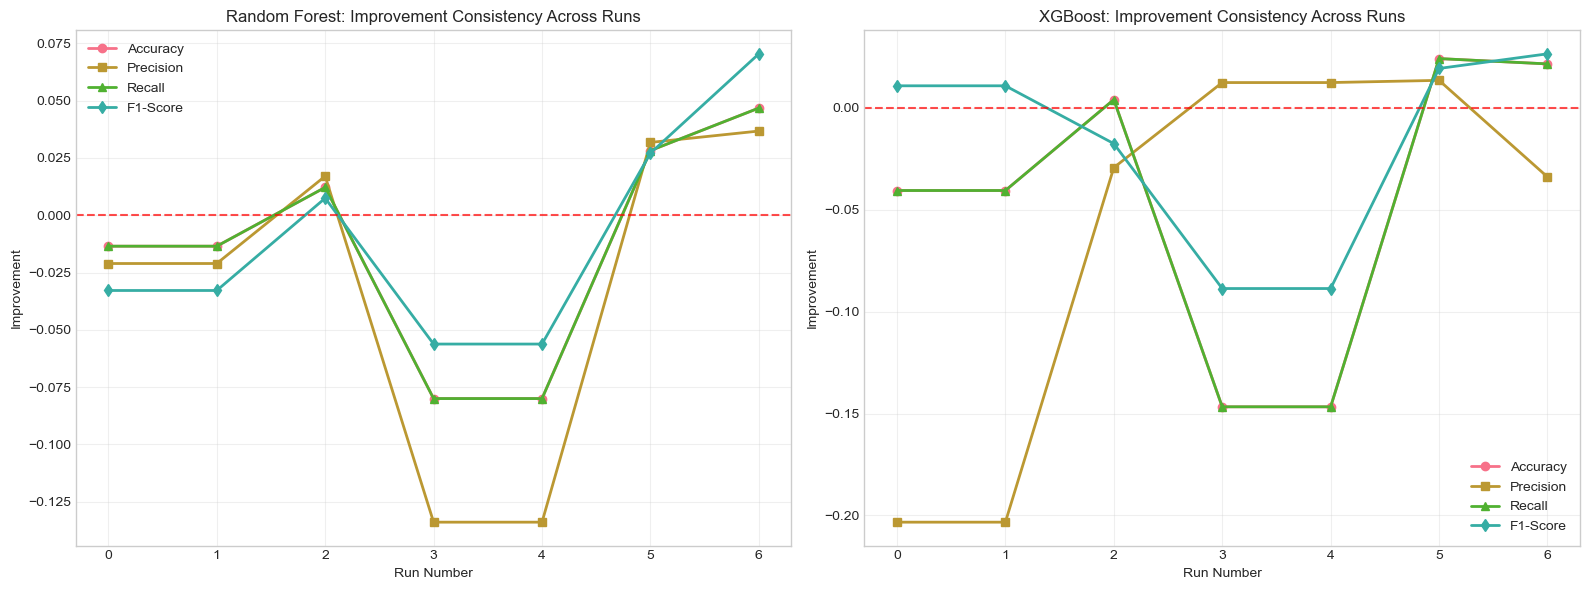

In [24]:
# 3. Improvement analysis visualization
if all_improvements_data:
    # Plot improvements across runs
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Performance Improvements: Enhanced vs Baseline Models', fontsize=16, fontweight='bold')
    
    improvement_metrics = ['accuracy_improvement', 'precision_improvement', 
                          'recall_improvement', 'f1_improvement']
    improvement_names = ['Accuracy Improvement', 'Precision Improvement', 
                        'Recall Improvement', 'F1-Score Improvement']
    
    for idx, (metric, metric_name) in enumerate(zip(improvement_metrics, improvement_names)):
        ax = axes[idx // 2, idx % 2]
        
        # Separate data by model type
        rf_improvements = combined_improvements[
            combined_improvements['model_pair'].str.contains('Random Forest')
        ][metric].values
        
        xgb_improvements = combined_improvements[
            combined_improvements['model_pair'].str.contains('XGBoost')
        ][metric].values
        
        # Create bar plot with error bars
        models = ['Random Forest', 'XGBoost']
        improvements = [rf_improvements, xgb_improvements]
        means = [np.mean(imp) for imp in improvements]
        stds = [np.std(imp) for imp in improvements]
        
        bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.7, 
                     color=['#1f77b4', '#ff7f0e'])
        
        # Add zero line
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        
        # Customize plot
        ax.set_title(metric_name)
        ax.set_ylabel('Improvement')
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mean, std in zip(bars, means, stds):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.001,
                   f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')
        
        # Add significance indicators (if mean > 2*std, likely significant)
        for i, (mean, std) in enumerate(zip(means, stds)):
            if abs(mean) > 2 * std:
                ax.text(i, mean + std + 0.005, '**', ha='center', va='bottom', 
                       fontsize=16, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Improvement consistency analysis
    plt.figure(figsize=(14, 6))
    
    # Create subplot for each model type
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Random Forest improvements over runs
    rf_data = combined_improvements[combined_improvements['model_pair'].str.contains('Random Forest')]
    if not rf_data.empty:
        runs = range(len(rf_data))
        ax1.plot(runs, rf_data['accuracy_improvement'], 'o-', label='Accuracy', linewidth=2)
        ax1.plot(runs, rf_data['precision_improvement'], 's-', label='Precision', linewidth=2)
        ax1.plot(runs, rf_data['recall_improvement'], '^-', label='Recall', linewidth=2)
        ax1.plot(runs, rf_data['f1_improvement'], 'd-', label='F1-Score', linewidth=2)
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        ax1.set_title('Random Forest: Improvement Consistency Across Runs')
        ax1.set_xlabel('Run Number')
        ax1.set_ylabel('Improvement')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # XGBoost improvements over runs
    xgb_data = combined_improvements[combined_improvements['model_pair'].str.contains('XGBoost')]
    if not xgb_data.empty:
        runs = range(len(xgb_data))
        ax2.plot(runs, xgb_data['accuracy_improvement'], 'o-', label='Accuracy', linewidth=2)
        ax2.plot(runs, xgb_data['precision_improvement'], 's-', label='Precision', linewidth=2)
        ax2.plot(runs, xgb_data['recall_improvement'], '^-', label='Recall', linewidth=2)
        ax2.plot(runs, xgb_data['f1_improvement'], 'd-', label='F1-Score', linewidth=2)
        ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        ax2.set_title('XGBoost: Improvement Consistency Across Runs')
        ax2.set_xlabel('Run Number')
        ax2.set_ylabel('Improvement')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Feature Selection Analysis

FEATURE SELECTION ANALYSIS
Runs with feature selection data: 7

Feature Selection Summary:
  Original features (avg): 115
  RF selected (avg): 22.7 ± 4.8
  XGBoost selected (avg): 27.1 ± 6.1
  RF reduction (avg): 80.2% ± 4.0%
  XGBoost reduction (avg): 76.3% ± 5.6%


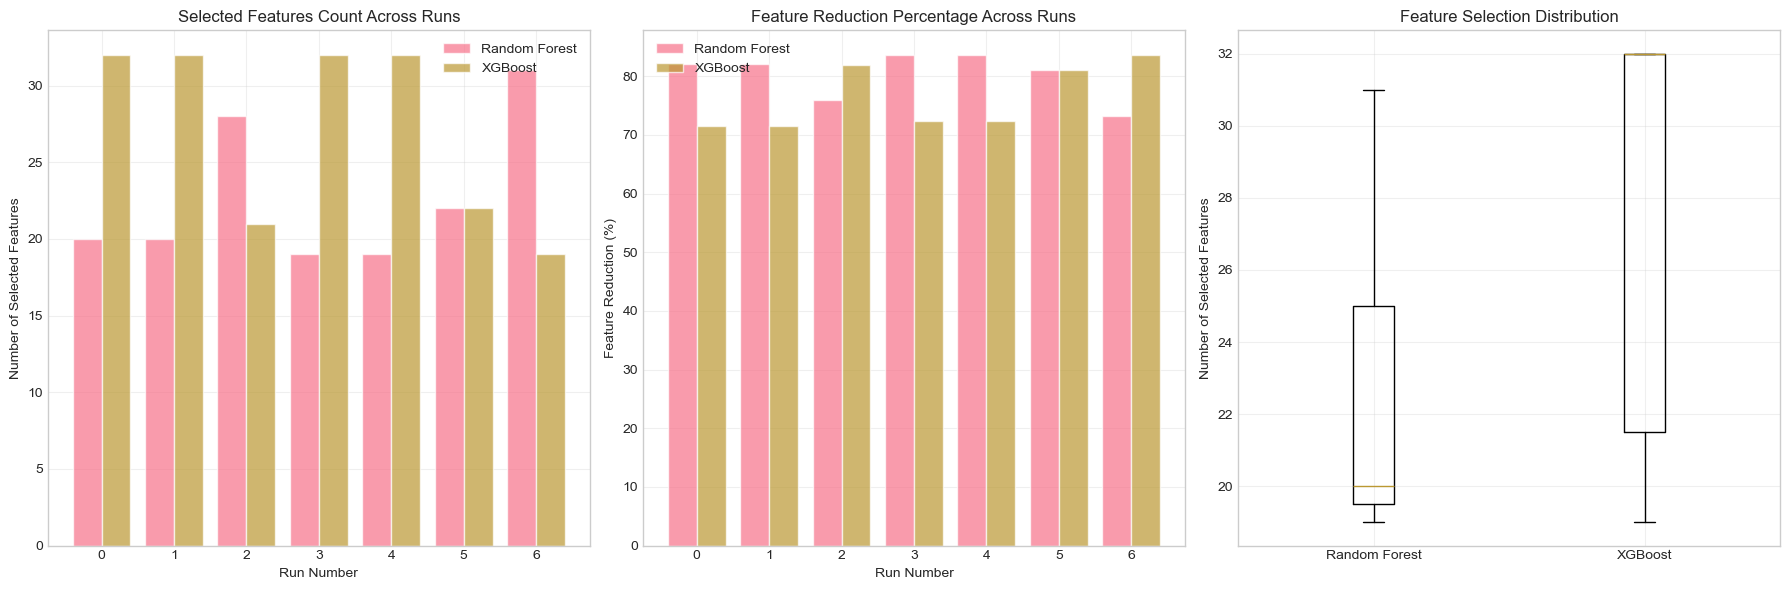

In [25]:
# Analyze feature selection effectiveness across runs
feature_selection_data = []

for run_dir in valid_runs:
    # Try to load feature selection information
    feature_names_file = os.path.join(run_dir, 'feature_names.pkl')
    selected_features_rf_file = os.path.join(run_dir, 'selected_features_rf.pkl')
    selected_features_xgb_file = os.path.join(run_dir, 'selected_features_xgb.pkl')
    
    if (os.path.exists(feature_names_file) and 
        os.path.exists(selected_features_rf_file) and 
        os.path.exists(selected_features_xgb_file)):
        
        try:
            # Load original feature names
            with open(feature_names_file, 'rb') as f:
                original_features = pickle.load(f)
            
            # Load selected features
            with open(selected_features_rf_file, 'rb') as f:
                selected_rf = pickle.load(f)
                # Handle different possible return formats from GA
                if isinstance(selected_rf, tuple):
                    selected_rf = selected_rf[2] if len(selected_rf) > 2 else selected_rf[0]
            
            with open(selected_features_xgb_file, 'rb') as f:
                selected_xgb = pickle.load(f)
                # Handle different possible return formats from GA
                if isinstance(selected_xgb, tuple):
                    selected_xgb = selected_xgb[2] if len(selected_xgb) > 2 else selected_xgb[0]
            
            feature_info = {
                'run_id': run_dir,
                'total_features': len(original_features),
                'rf_selected': len(selected_rf),
                'xgb_selected': len(selected_xgb),
                'rf_reduction_pct': (1 - len(selected_rf) / len(original_features)) * 100,
                'xgb_reduction_pct': (1 - len(selected_xgb) / len(original_features)) * 100,
                'rf_selected_features': selected_rf,
                'xgb_selected_features': selected_xgb
            }
            
            feature_selection_data.append(feature_info)
            
        except Exception as e:
            print(f"Error loading feature data from {run_dir}: {str(e)}")

if feature_selection_data:
    print("="*80)
    print("FEATURE SELECTION ANALYSIS")
    print("="*80)
    
    feature_df = pd.DataFrame(feature_selection_data)
    
    print(f"Runs with feature selection data: {len(feature_df)}")
    print(f"\nFeature Selection Summary:")
    print(f"  Original features (avg): {feature_df['total_features'].mean():.0f}")
    print(f"  RF selected (avg): {feature_df['rf_selected'].mean():.1f} ± {feature_df['rf_selected'].std():.1f}")
    print(f"  XGBoost selected (avg): {feature_df['xgb_selected'].mean():.1f} ± {feature_df['xgb_selected'].std():.1f}")
    print(f"  RF reduction (avg): {feature_df['rf_reduction_pct'].mean():.1f}% ± {feature_df['rf_reduction_pct'].std():.1f}%")
    print(f"  XGBoost reduction (avg): {feature_df['xgb_reduction_pct'].mean():.1f}% ± {feature_df['xgb_reduction_pct'].std():.1f}%")
    
    # Visualize feature selection consistency
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Feature count comparison
    ax1 = axes[0]
    x = range(len(feature_df))
    ax1.bar([i - 0.2 for i in x], feature_df['rf_selected'], width=0.4, 
            label='Random Forest', alpha=0.7)
    ax1.bar([i + 0.2 for i in x], feature_df['xgb_selected'], width=0.4, 
            label='XGBoost', alpha=0.7)
    ax1.set_xlabel('Run Number')
    ax1.set_ylabel('Number of Selected Features')
    ax1.set_title('Selected Features Count Across Runs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Reduction percentage
    ax2 = axes[1]
    ax2.bar([i - 0.2 for i in x], feature_df['rf_reduction_pct'], width=0.4, 
            label='Random Forest', alpha=0.7)
    ax2.bar([i + 0.2 for i in x], feature_df['xgb_reduction_pct'], width=0.4, 
            label='XGBoost', alpha=0.7)
    ax2.set_xlabel('Run Number')
    ax2.set_ylabel('Feature Reduction (%)')
    ax2.set_title('Feature Reduction Percentage Across Runs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Box plot of feature counts
    ax3 = axes[2]
    data_to_plot = [feature_df['rf_selected'], feature_df['xgb_selected']]
    ax3.boxplot(data_to_plot, labels=['Random Forest', 'XGBoost'])
    ax3.set_ylabel('Number of Selected Features')
    ax3.set_title('Feature Selection Distribution')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No feature selection data found in run directories")


FEATURE SELECTION CONSISTENCY ANALYSIS
Random Forest - Most frequently selected features:
  Total unique features selected: 71
  Features selected in all runs: 0
  Top 10 most selected features:
     1. Volatility_50: 6/7 runs (85.7%)
     2. ADX_14: 6/7 runs (85.7%)
     3. Returns_Kurtosis_50: 5/7 runs (71.4%)
     4. Normalized_Vol_10: 5/7 runs (71.4%)
     5. Normalized_Vol_50: 5/7 runs (71.4%)
     6. Volatility_20: 4/7 runs (57.1%)
     7. Chaikin_Vol_20: 4/7 runs (57.1%)
     8. Returns_Kurtosis_20: 4/7 runs (57.1%)
     9. Volatility_10: 4/7 runs (57.1%)
    10. BB_Middle_20: 3/7 runs (42.9%)

XGBoost - Most frequently selected features:
  Total unique features selected: 82
  Features selected in all runs: 0
  Top 10 most selected features:
     1. SMA_Dist_100: 6/7 runs (85.7%)
     2. Autocorr_5: 6/7 runs (85.7%)
     3. Normalized_Vol_10: 5/7 runs (71.4%)
     4. Volatility_20: 5/7 runs (71.4%)
     5. ADX_14: 5/7 runs (71.4%)
     6. EMA_Dist_50: 5/7 runs (71.4%)
     7. S

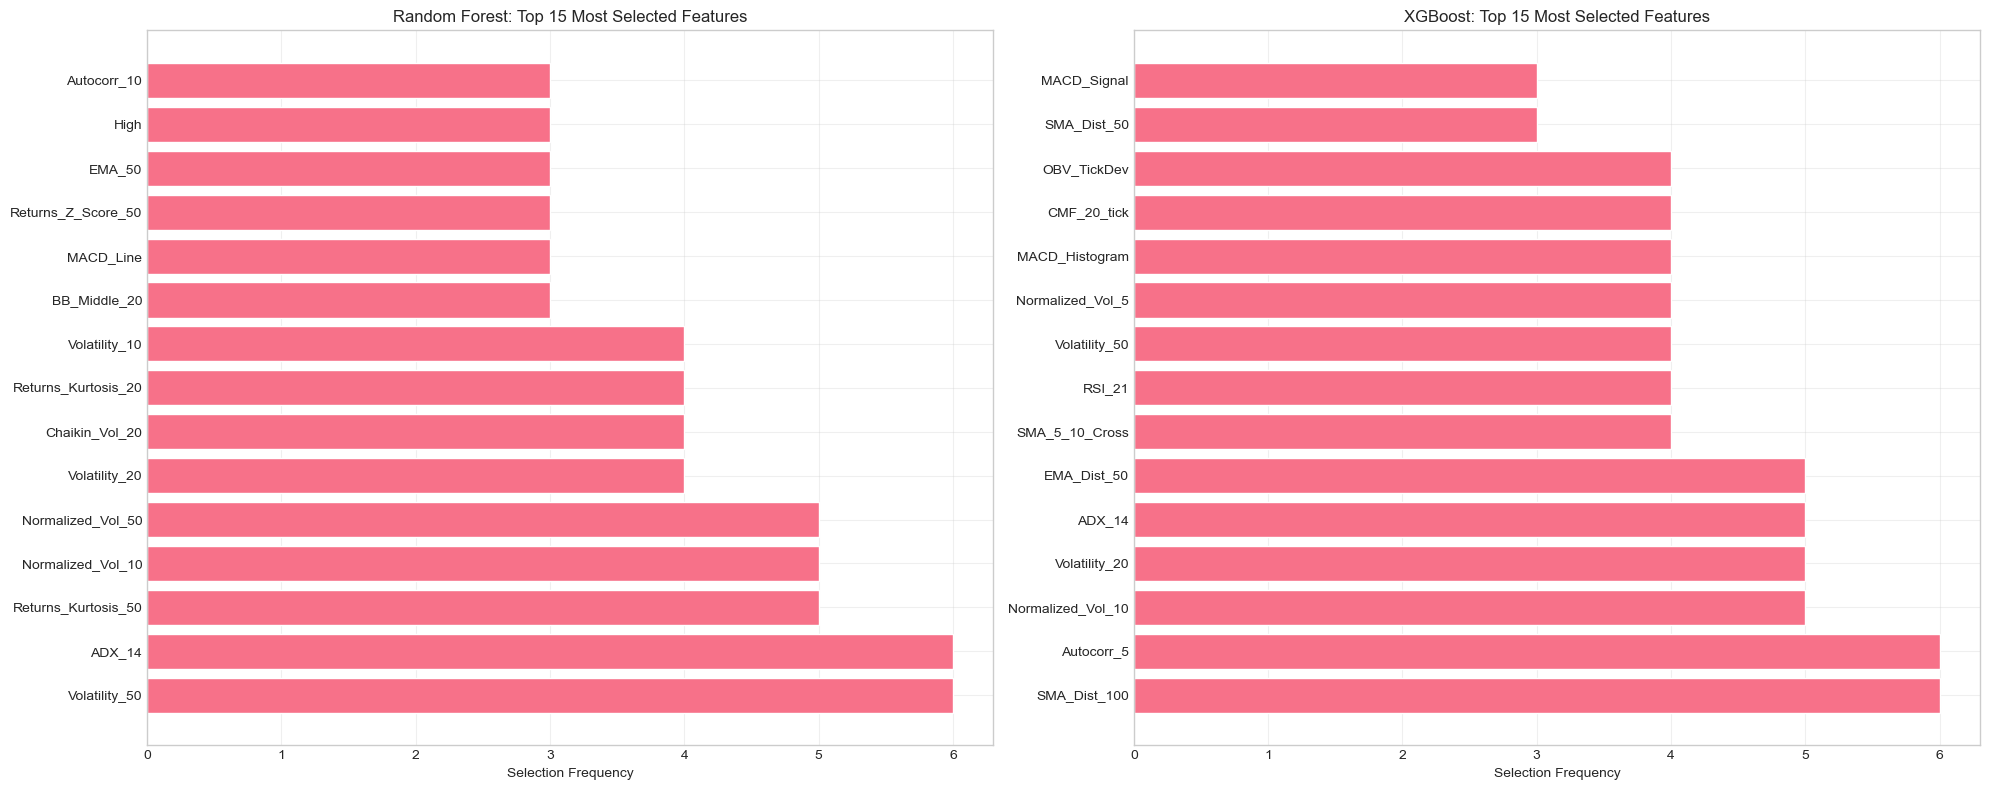

In [26]:
# Analyze feature overlap and consistency across runs
if feature_selection_data and len(feature_selection_data) > 1:
    print("\n" + "="*80)
    print("FEATURE SELECTION CONSISTENCY ANALYSIS")
    print("="*80)
    
    # Analyze Random Forest feature selection consistency
    all_rf_features = []
    for run_data in feature_selection_data:
        all_rf_features.extend(run_data['rf_selected_features'])
    
    rf_feature_counts = pd.Series(all_rf_features).value_counts()
    
    # Analyze XGBoost feature selection consistency
    all_xgb_features = []
    for run_data in feature_selection_data:
        all_xgb_features.extend(run_data['xgb_selected_features'])
    
    xgb_feature_counts = pd.Series(all_xgb_features).value_counts()
    
    print(f"Random Forest - Most frequently selected features:")
    print(f"  Total unique features selected: {len(rf_feature_counts)}")
    print(f"  Features selected in all runs: {len(rf_feature_counts[rf_feature_counts == len(feature_selection_data)])}")
    print(f"  Top 10 most selected features:")
    for i, (feature, count) in enumerate(rf_feature_counts.head(10).items()):
        print(f"    {i+1:2d}. {feature}: {count}/{len(feature_selection_data)} runs ({count/len(feature_selection_data)*100:.1f}%)")
    
    print(f"\nXGBoost - Most frequently selected features:")
    print(f"  Total unique features selected: {len(xgb_feature_counts)}")
    print(f"  Features selected in all runs: {len(xgb_feature_counts[xgb_feature_counts == len(feature_selection_data)])}")
    print(f"  Top 10 most selected features:")
    for i, (feature, count) in enumerate(xgb_feature_counts.head(10).items()):
        print(f"    {i+1:2d}. {feature}: {count}/{len(feature_selection_data)} runs ({count/len(feature_selection_data)*100:.1f}%)")
    
    # Find common features between RF and XGBoost
    rf_top_features = set(rf_feature_counts.head(20).index)
    xgb_top_features = set(xgb_feature_counts.head(20).index)
    common_top_features = rf_top_features & xgb_top_features
    
    print(f"\nCommon features in top 20 for both models: {len(common_top_features)}")
    if common_top_features:
        print("Common features:")
        for feature in sorted(common_top_features):
            rf_freq = rf_feature_counts[feature] / len(feature_selection_data) * 100
            xgb_freq = xgb_feature_counts[feature] / len(feature_selection_data) * 100
            print(f"  • {feature}: RF {rf_freq:.1f}%, XGBoost {xgb_freq:.1f}%")
    
    # Visualize feature selection frequency
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Random Forest top features
    top_rf = rf_feature_counts.head(15)
    ax1.barh(range(len(top_rf)), top_rf.values)
    ax1.set_yticks(range(len(top_rf)))
    ax1.set_yticklabels(top_rf.index, fontsize=10)
    ax1.set_xlabel('Selection Frequency')
    ax1.set_title('Random Forest: Top 15 Most Selected Features')
    ax1.grid(True, alpha=0.3)
    
    # XGBoost top features
    top_xgb = xgb_feature_counts.head(15)
    ax2.barh(range(len(top_xgb)), top_xgb.values)
    ax2.set_yticks(range(len(top_xgb)))
    ax2.set_yticklabels(top_xgb.index, fontsize=10)
    ax2.set_xlabel('Selection Frequency')
    ax2.set_title('XGBoost: Top 15 Most Selected Features')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Effect Size and Practical Significance Analysis

In [27]:
# Comprehensive effect size analysis and practical significance
if all_performance_data and 'statistical_results' in locals():
    print("="*80)
    print("EFFECT SIZE AND PRACTICAL SIGNIFICANCE ANALYSIS")
    print("="*80)
    
    # Create summary table of all effect sizes
    effect_summary = []
    
    for comparison, metrics_data in statistical_results.items():
        model_name = comparison.replace('_vs_', ' vs ').replace('_', ' ')
        
        for metric, test_results in metrics_data.items():
            effect_info = {
                'comparison': model_name,
                'metric': metric,
                'effect_size': test_results['effect_size']['cohens_d'],
                'interpretation': test_results['effect_size']['interpretation'],
                'improvement': test_results['descriptive']['improvement'],
                'improvement_pct': test_results['descriptive']['improvement_percentage'],
                'baseline_mean': test_results['descriptive']['baseline_mean'],
                'enhanced_mean': test_results['descriptive']['enhanced_mean']
            }
            
            # Add statistical significance if available
            if 'paired_t_test' in test_results:
                effect_info['p_value_paired'] = test_results['paired_t_test']['p_value']
            if 'mann_whitney_test' in test_results:
                effect_info['p_value_mw'] = test_results['mann_whitney_test']['p_value']
            
            effect_summary.append(effect_info)
    
    effect_df = pd.DataFrame(effect_summary)
    
    print("Effect Size Summary:")
    print("-" * 60)
    
    # Group by model type
    model_types = effect_df['comparison'].str.extract(r'(Random Forest|XGBoost|ANN)')[0].unique()
    
    for model_type in model_types:
        if pd.isna(model_type):
            continue
            
        print(f"\n{model_type.upper()} MODEL:")
        model_data = effect_df[effect_df['comparison'].str.contains(model_type, na=False)]
        
        for _, row in model_data.iterrows():
            significance = ""
            if 'p_value_paired' in row and not pd.isna(row['p_value_paired']):
                p_val = row['p_value_paired']
                significance = " ***" if p_val < 0.001 else " **" if p_val < 0.01 else " *" if p_val < 0.05 else " ns"
            
            print(f"  {row['metric'].capitalize()}:")
            print(f"    • Effect Size: {row['effect_size']:.4f} ({row['interpretation']})")
            print(f"    • Improvement: {row['improvement']:+.4f} ({row['improvement_pct']:+.2f}%){significance}")
            print(f"    • Baseline→Enhanced: {row['baseline_mean']:.4f} → {row['enhanced_mean']:.4f}")
    
    # Summary of practical significance
    print("\n" + "="*80)
    print("PRACTICAL SIGNIFICANCE SUMMARY")
    print("="*80)
    
    # Count effect sizes by interpretation
    effect_counts = effect_df['interpretation'].value_counts()
    print("Effect Size Distribution:")
    for interpretation, count in effect_counts.items():
        percentage = count / len(effect_df) * 100
        print(f"  • {interpretation}: {count} ({percentage:.1f}%)")
    
    # Best performing improvements
    print(f"\nLargest Improvements (by effect size):")
    top_improvements = effect_df.nlargest(5, 'effect_size')
    for _, row in top_improvements.iterrows():
        print(f"  • {row['comparison']} - {row['metric']}: d = {row['effect_size']:.4f} ({row['interpretation']})")
    
    print(f"\nOverall Assessment:")
    large_effects = len(effect_df[effect_df['interpretation'] == 'Large'])
    medium_effects = len(effect_df[effect_df['interpretation'] == 'Medium'])
    total_effects = len(effect_df)
    
    if large_effects > 0:
        print(f"  • {large_effects}/{total_effects} comparisons show LARGE practical significance")
    if medium_effects > 0:
        print(f"  • {medium_effects}/{total_effects} comparisons show MEDIUM practical significance")
    
    substantial_improvements = large_effects + medium_effects
    if substantial_improvements > total_effects / 2:
        print(f"  • {substantial_improvements}/{total_effects} ({substantial_improvements/total_effects*100:.1f}%) show substantial improvement")
        print("  ✓ GA enhancement demonstrates meaningful practical benefits")
    else:
        print(f"  • {substantial_improvements}/{total_effects} ({substantial_improvements/total_effects*100:.1f}%) show substantial improvement")
        print("  ⚠️ GA enhancement shows limited practical benefits")
        
else:
    print("Statistical results not available for effect size analysis")

EFFECT SIZE AND PRACTICAL SIGNIFICANCE ANALYSIS
Effect Size Summary:
------------------------------------------------------------

RANDOM FOREST MODEL:
  Accuracy:
    • Effect Size: -0.1415 (Negligible)
    • Improvement: -0.0143 (-4.25%) ns
    • Baseline→Enhanced: 0.3362 → 0.3219
  Precision:
    • Effect Size: -0.2560 (Small)
    • Improvement: -0.0321 (-10.11%) ns
    • Baseline→Enhanced: 0.3171 → 0.2850
  Recall:
    • Effect Size: -0.1415 (Negligible)
    • Improvement: -0.0143 (-4.25%) ns
    • Baseline→Enhanced: 0.3362 → 0.3219
  F1_score:
    • Effect Size: -0.0842 (Negligible)
    • Improvement: -0.0104 (-3.76%) ns
    • Baseline→Enhanced: 0.2776 → 0.2671

XGBOOST MODEL:
  Accuracy:
    • Effect Size: -0.7034 (Medium)
    • Improvement: -0.0464 (-11.53%) ns
    • Baseline→Enhanced: 0.4021 → 0.3558
  Precision:
    • Effect Size: -1.0355 (Large)
    • Improvement: -0.0616 (-14.25%) ns
    • Baseline→Enhanced: 0.4326 → 0.3710
  Recall:
    • Effect Size: -0.7034 (Medium)
    •

## 8. Final Conclusions and Recommendations

In [28]:
# Generate comprehensive conclusions and save evaluation report
if all_performance_data:
    print("="*80)
    print("COMPREHENSIVE EVALUATION CONCLUSIONS")
    print("="*80)
    
    # Create comprehensive evaluation report
    report = {
        'evaluation_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'total_runs_analyzed': len(valid_runs),
        'total_model_evaluations': len(combined_performance),
        'summary': {},
        'conclusions': [],
        'recommendations': []
    }
    
    # Statistical summary
    if 'statistical_results' in locals():
        significant_improvements = 0
        total_comparisons = 0
        
        for comparison, metrics_data in statistical_results.items():
            for metric, test_results in metrics_data.items():
                total_comparisons += 1
                if ('paired_t_test' in test_results and 
                    test_results['paired_t_test']['p_value'] < 0.05):
                    significant_improvements += 1
        
        significance_rate = significant_improvements / total_comparisons * 100 if total_comparisons > 0 else 0
        
        print(f"STATISTICAL SIGNIFICANCE ANALYSIS:")
        print(f"  • Total comparisons: {total_comparisons}")
        print(f"  • Statistically significant improvements: {significant_improvements}")
        print(f"  • Significance rate: {significance_rate:.1f}%")
        
        report['summary']['statistical_significance'] = {
            'total_comparisons': total_comparisons,
            'significant_improvements': significant_improvements,
            'significance_rate': significance_rate
        }
    
    # Effect size summary
    if 'effect_df' in locals():
        large_effects = len(effect_df[effect_df['interpretation'] == 'Large'])
        medium_effects = len(effect_df[effect_df['interpretation'] == 'Medium'])
        small_effects = len(effect_df[effect_df['interpretation'] == 'Small'])
        negligible_effects = len(effect_df[effect_df['interpretation'] == 'Negligible'])
        
        print(f"\nEFFECT SIZE ANALYSIS:")
        print(f"  • Large effects: {large_effects}")
        print(f"  • Medium effects: {medium_effects}")
        print(f"  • Small effects: {small_effects}")
        print(f"  • Negligible effects: {negligible_effects}")
        
        report['summary']['effect_sizes'] = {
            'large': large_effects,
            'medium': medium_effects,
            'small': small_effects,
            'negligible': negligible_effects
        }
    
    # Performance improvement summary
    if all_improvements_data:
        avg_accuracy_improvement = combined_improvements['accuracy_improvement'].mean()
        avg_f1_improvement = combined_improvements['f1_improvement'].mean()
        
        print(f"\nPERFORMANCE IMPROVEMENTS:")
        print(f"  • Average accuracy improvement: {avg_accuracy_improvement:+.4f}")
        print(f"  • Average F1-score improvement: {avg_f1_improvement:+.4f}")
        
        report['summary']['average_improvements'] = {
            'accuracy': avg_accuracy_improvement,
            'f1_score': avg_f1_improvement
        }
    
    # Feature selection effectiveness
    if feature_selection_data:
        avg_rf_reduction = np.mean([run['rf_reduction_pct'] for run in feature_selection_data])
        avg_xgb_reduction = np.mean([run['xgb_reduction_pct'] for run in feature_selection_data])
        
        print(f"\nFEATURE SELECTION EFFECTIVENESS:")
        print(f"  • Random Forest avg. reduction: {avg_rf_reduction:.1f}%")
        print(f"  • XGBoost avg. reduction: {avg_xgb_reduction:.1f}%")
        
        report['summary']['feature_selection'] = {
            'rf_avg_reduction': avg_rf_reduction,
            'xgb_avg_reduction': avg_xgb_reduction
        }
    
    # Generate conclusions based on analysis
    print(f"\n{'='*80}")
    print("CONCLUSIONS")
    print("="*80)
    
    conclusions = []
    
    # Statistical significance conclusion
    if 'significance_rate' in locals():
        if significance_rate >= 50:
            conclusion = f"✓ GA enhancement shows statistically significant improvements in {significance_rate:.1f}% of comparisons"
            conclusions.append(conclusion)
            print(f"1. {conclusion}")
        else:
            conclusion = f"⚠️ GA enhancement shows limited statistical significance ({significance_rate:.1f}% of comparisons)"
            conclusions.append(conclusion)
            print(f"1. {conclusion}")
    
    # Effect size conclusion
    if 'effect_df' in locals():
        substantial_effects = large_effects + medium_effects
        total_effects = len(effect_df)
        if substantial_effects >= total_effects * 0.5:
            conclusion = f"✓ GA enhancement demonstrates substantial practical significance ({substantial_effects}/{total_effects} comparisons)"
            conclusions.append(conclusion)
            print(f"2. {conclusion}")
        else:
            conclusion = f"⚠️ GA enhancement shows limited practical significance ({substantial_effects}/{total_effects} comparisons)"
            conclusions.append(conclusion)
            print(f"2. {conclusion}")
    
    # Model-specific conclusions
    if all_improvements_data:
        rf_improvements = combined_improvements[combined_improvements['model_pair'].str.contains('Random Forest')]
        xgb_improvements = combined_improvements[combined_improvements['model_pair'].str.contains('XGBoost')]
        
        if not rf_improvements.empty:
            rf_avg_acc = rf_improvements['accuracy_improvement'].mean()
            rf_consistency = rf_improvements['accuracy_improvement'].std()
            if rf_avg_acc > 0 and rf_consistency < 0.05:
                conclusion = f"✓ Random Forest shows consistent positive improvements (avg: {rf_avg_acc:+.4f}, std: {rf_consistency:.4f})"
            else:
                conclusion = f"⚠️ Random Forest shows inconsistent improvements (avg: {rf_avg_acc:+.4f}, std: {rf_consistency:.4f})"
            conclusions.append(conclusion)
            print(f"3. {conclusion}")
        
        if not xgb_improvements.empty:
            xgb_avg_acc = xgb_improvements['accuracy_improvement'].mean()
            xgb_consistency = xgb_improvements['accuracy_improvement'].std()
            if xgb_avg_acc > 0 and xgb_consistency < 0.05:
                conclusion = f"✓ XGBoost shows consistent positive improvements (avg: {xgb_avg_acc:+.4f}, std: {xgb_consistency:.4f})"
            else:
                conclusion = f"⚠️ XGBoost shows inconsistent improvements (avg: {xgb_avg_acc:+.4f}, std: {xgb_consistency:.4f})"
            conclusions.append(conclusion)
            print(f"4. {conclusion}")
    
    # Feature selection conclusion
    if feature_selection_data:
        if avg_rf_reduction > 50 and avg_xgb_reduction > 50:
            conclusion = f"✓ GA feature selection effectively reduces dimensionality (RF: {avg_rf_reduction:.1f}%, XGB: {avg_xgb_reduction:.1f}%)"
            conclusions.append(conclusion)
            print(f"5. {conclusion}")
    
    # Generate recommendations
    print(f"\n{'='*80}")
    print("RECOMMENDATIONS")
    print("="*80)
    
    recommendations = []
    
    if 'significance_rate' in locals() and significance_rate < 50:
        rec = "Consider increasing GA population size or generations for more robust feature selection"
        recommendations.append(rec)
        print(f"1. {rec}")
    
    if 'effect_df' in locals() and large_effects == 0:
        rec = "Explore different GA fitness functions or incorporate domain-specific knowledge"
        recommendations.append(rec)
        print(f"2. {rec}")
    
    if all_improvements_data and len(valid_runs) < 10:
        rec = "Conduct more experimental runs to increase statistical power"
        recommendations.append(rec)
        print(f"3. {rec}")
    
    if feature_selection_data:
        rec = "Analyze most frequently selected features for domain insights"
        recommendations.append(rec)
        print(f"4. {rec}")
    
    rec = "Consider ensemble methods combining multiple GA-enhanced models"
    recommendations.append(rec)
    print(f"5. {rec}")
    
    # Save comprehensive report
    report['conclusions'] = conclusions
    report['recommendations'] = recommendations
    
    # Save to files in performance_results directory
    with open('performance_results/performance_evaluation_report.json', 'w') as f:
        json.dump(report, f, indent=2, default=str)
    
    # Save detailed results
    if all_performance_data:
        combined_performance.to_csv('performance_results/combined_performance_results.csv', index=False)
    if all_improvements_data:
        combined_improvements.to_csv('performance_results/combined_improvements_results.csv', index=False)
    if 'effect_df' in locals():
        effect_df.to_csv('performance_results/effect_size_analysis.csv', index=False)
    
    print(f"\n{'='*80}")
    print("EVALUATION COMPLETE")
    print("="*80)
    print("Files saved in performance_results directory:")
    print("  • performance_evaluation_report.json")
    print("  • combined_performance_results.csv")
    print("  • combined_improvements_results.csv")
    print("  • effect_size_analysis.csv")
    print("="*80)

else:
    print("No performance data available for comprehensive evaluation")

COMPREHENSIVE EVALUATION CONCLUSIONS
STATISTICAL SIGNIFICANCE ANALYSIS:
  • Total comparisons: 8
  • Statistically significant improvements: 0
  • Significance rate: 0.0%

EFFECT SIZE ANALYSIS:
  • Large effects: 1
  • Medium effects: 2
  • Small effects: 2
  • Negligible effects: 3

PERFORMANCE IMPROVEMENTS:
  • Average accuracy improvement: -0.0303
  • Average F1-score improvement: -0.0143

FEATURE SELECTION EFFECTIVENESS:
  • Random Forest avg. reduction: 80.2%
  • XGBoost avg. reduction: 76.3%

CONCLUSIONS
1. ⚠️ GA enhancement shows limited statistical significance (0.0% of comparisons)
2. ⚠️ GA enhancement shows limited practical significance (3/8 comparisons)
3. ⚠️ Random Forest shows inconsistent improvements (avg: -0.0143, std: 0.0498)
4. ⚠️ XGBoost shows inconsistent improvements (avg: -0.0464, std: 0.0734)
5. ✓ GA feature selection effectively reduces dimensionality (RF: 80.2%, XGB: 76.3%)

RECOMMENDATIONS
1. Consider increasing GA population size or generations for more robu